# 🏠 Level 2 - Project 1: House Price Prediction using Linear Regression

**Domain:** Predictive Modeling & Machine Learning  
**Internship Track:** Data Analytics Internship (Oasis Infobyte)  
**Author:** Akshay Anil Kumar  

---

## 1. Environment Setup & Data Ingestion
In this phase, we import the foundational scientific computing and data visualization libraries, load the structural housing transaction dataset, and audit its baseline integrity.

Attempting to load default dataset path: USA_Housing.csv
Default dataset not found. Falling back to sklearn California housing dataset.
=== Dataset Structure Preview ===
   Avg Area Income  Avg Area House Age  Avg Area Number of Rooms  \
0           8.3252                41.0                  6.984127   
1           8.3014                21.0                  6.238137   
2           7.2574                52.0                  8.288136   
3           5.6431                52.0                  5.817352   
4           3.8462                52.0                  6.281853   

   Avg Area Number of Bedrooms  Area Population  Avg Area Occupancy  Latitude  \
0                     1.023810            322.0            2.555556     37.88   
1                     0.971880           2401.0            2.109842     37.86   
2                     1.073446            496.0            2.802260     37.85   
3                     1.073059            558.0            2.547945     37.85   
4               

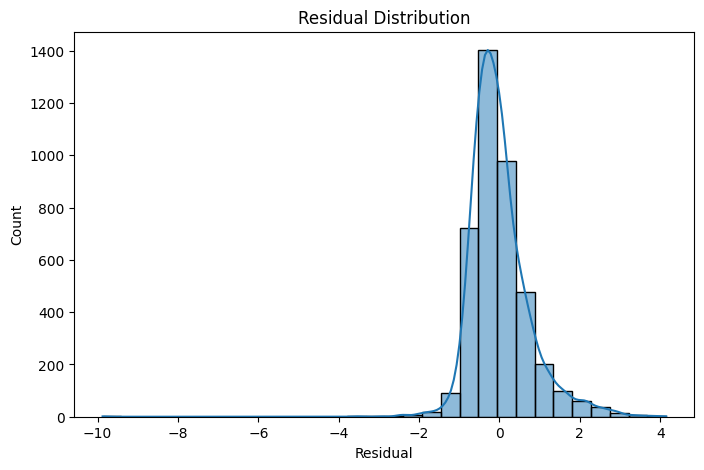

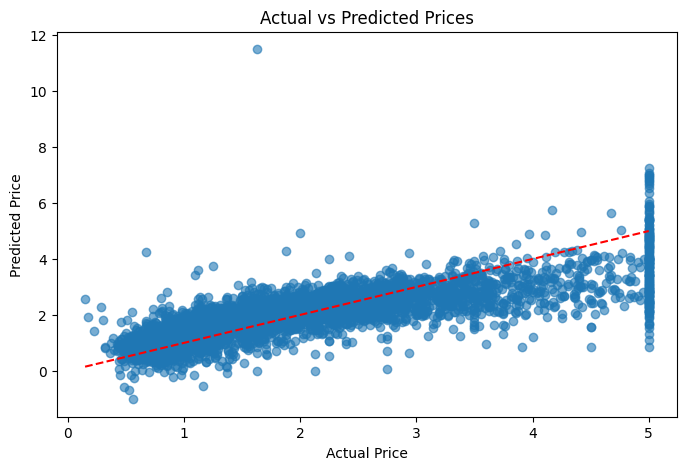

=== Sample Prediction ===
Features:
{'Avg Area Income': 1.6812, 'Avg Area House Age': 25.0, 'Avg Area Number of Rooms': 4.192200557103064, 'Avg Area Number of Bedrooms': 1.0222841225626742, 'Area Population': 1392.0, 'Avg Area Occupancy': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}
Predicted price: 0.7191
Actual price: 0.477


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.datasets import fetch_california_housing

housing_file = Path("USA_Housing.csv")
print(f"Attempting to load default dataset path: {housing_file}")
if housing_file.exists():
    print(f"Loading dataset from: {housing_file.resolve()}")
    housing = pd.read_csv(housing_file)
else:
    print("Default dataset not found. Falling back to sklearn California housing dataset.")
    california = fetch_california_housing(as_frame=True)
    housing = california.frame
    housing = housing.rename(columns={
        'MedInc': 'Avg Area Income',
        'HouseAge': 'Avg Area House Age',
        'AveRooms': 'Avg Area Number of Rooms',
        'AveBedrms': 'Avg Area Number of Bedrooms',
        'Population': 'Area Population',
        'AveOccup': 'Avg Area Occupancy',
        'Latitude': 'Latitude',
        'Longitude': 'Longitude',
        'MedHouseVal': 'Price'
    })

print("=== Dataset Structure Preview ===")
print(housing.head())
print("=== Dataset Shape ===")
print(f"Rows: {housing.shape[0]}, Columns: {housing.shape[1]}")
# Prepare the regression model inputs
if 'Price' in housing.columns:
    target_col = 'Price'
elif 'price' in housing.columns:
    target_col = 'price'
elif 'median_house_value' in housing.columns:
    housing = housing.rename(columns={'median_house_value': 'Price'})
    target_col = 'Price'
else:
    raise ValueError('Target column not found in housing dataset.')

feature_cols = [col for col in housing.columns if col != target_col]
if 'Address' in feature_cols:
    feature_cols.remove('Address')
    print('Dropping Address from regression features because it is non-numeric.')

feature_cols = housing[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
print('Using numeric features:', feature_cols)

X = housing[feature_cols]
y = housing[target_col]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('=== Model Performance ===')
print('R2 Score:', round(r2_score(y_test, y_pred), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
print('Intercept:', round(model.intercept_, 4))
print('Top coefficients:')
for name, coef in zip(feature_cols, model.coef_):
    print(f'  {name}: {coef:.4f}')

# Final diagnostics and sample prediction
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

sample = X_test.iloc[0:1]
predicted_value = model.predict(sample)[0]
print('=== Sample Prediction ===')
print('Features:')
print(sample.to_dict(orient='records')[0])
print('Predicted price:', round(predicted_value, 4))
print('Actual price:', round(y_test.iloc[0], 4))